In [2]:
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [4]:
print("all libraries are loaded")

all libraries are loaded


In [5]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.shape)

(7043, 21)


In [7]:
print(df.info())
print("/ncolumn names:",df.columns)
print("/ndata types:",df.dtypes)
print("/nmissing values:",df.isnull().sum())
print("/nunique values:",df.nunique)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Null values in TotalCharges:",df['TotalCharges'].isnull().sum())

Null values in TotalCharges: 11


In [9]:
df.dropna(inplace=True)
print("Cleanes space:",df.shape)

Cleanes space: (7032, 21)


In [10]:
print(df['Churn'].value_counts())
print("Churn rate",round(df['Churn']))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn rate 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: object


In [11]:
print(df['Churn'].value_counts())
print("Churn rate",round(df['Churn'].value_counts(normalize=True)['Yes']*100,2),'%')

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn rate 26.58 %


In [12]:
df.groupby('Contract')["Churn"].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

In [13]:
df.groupby('Churn')['tenure'].mean()


,tenure
Churn,
No,37.650010
Yes,17.979133


In [14]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


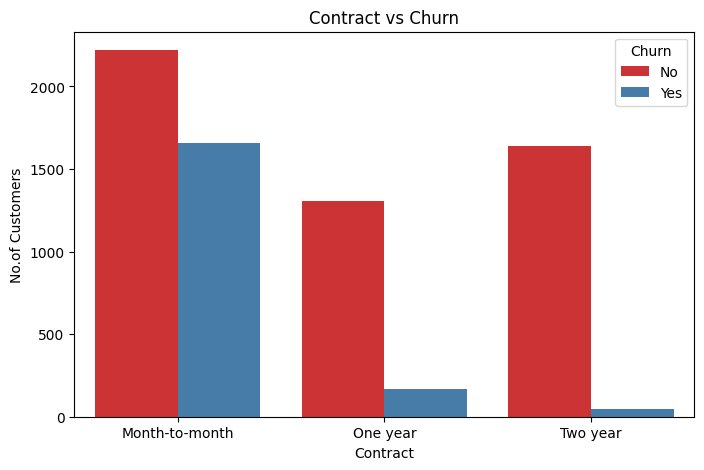

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn',data=df,palette='Set1')
plt.title('Contract vs Churn')
plt.xlabel('Contract')
plt.ylabel('No.of Customers')
plt.show()

/tmp/ipykernel_1424/2705847484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='tenure',data=df,palette='Set2')


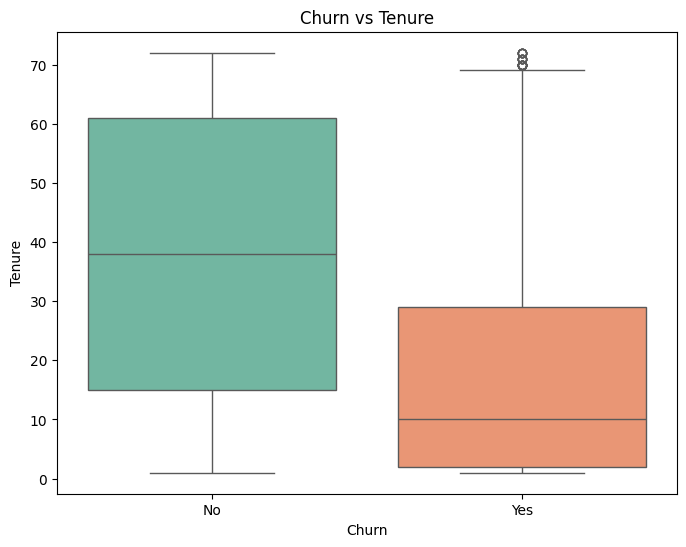

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='tenure',data=df,palette='Set2')
plt.title('Churn vs Tenure')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

/tmp/ipykernel_1424/1964882103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set2')


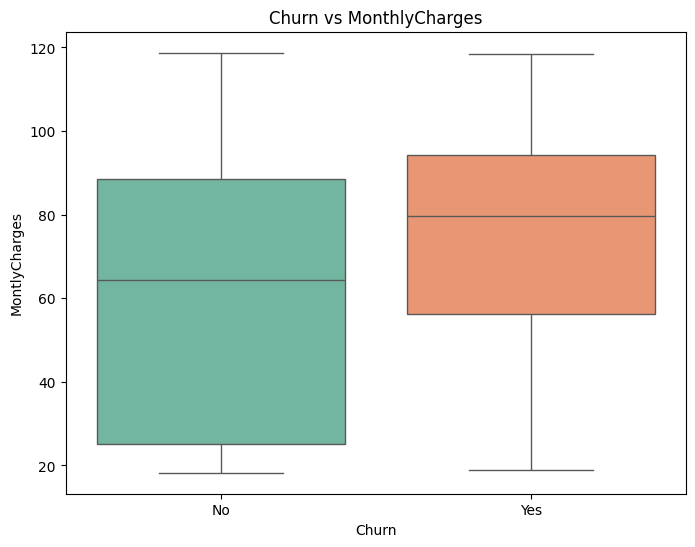

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df,palette='Set2')
plt.title('Churn vs MonthlyCharges')
plt.xlabel('Churn')
plt.ylabel('MontlyCharges')
plt.show()

In [18]:
binary_cols=['gender','Dependents','Partner','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col]=df[col].map({'Yes':1,'No':0,'Male':1,'Female':0})
print("Label Encoding")
print(df[['gender','Partner','Churn']].head())

Label Encoding
   gender  Partner  Churn
0       0        1      0
1       1        0      0
2       1        0      1
3       1        0      0
4       0        0      1


In [19]:
print(df['gender'].unique())
print(df['Partner'].unique())
print(df['Churn'].unique())

[0 1]
[1 0]
[0 1]


In [20]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print(df['gender'].unique())
print(df['Partner'].unique())
print(df['Churn'].unique())

['Female' 'Male']
['Yes' 'No']
['No' 'Yes']


In [21]:
df=pd.get_dummies(df,columns=['Contract','PaymentMethod','InternetService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'],drop_first=True)
print("Shape after encoding",df.shape)
print(df.head())

Shape after encoding (7032, 32)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0              Yes           29.85         29.85  ...   
1               No           56.95       1889.50  ...   
2              Yes           53.85        108.15  ...   
3               No           42.30       1840.75  ...   
4              Yes           70.70        151.65  ...   

  OnlineBackup_No internet service  OnlineBackup_Yes  \
0                            False              True   
1                            Fal

In [22]:
df=df.astype({col:int for col in df.select_dtypes(bool).columns})
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0              Yes           29.85         29.85  ...   
1               No           56.95       1889.50  ...   
2              Yes           53.85        108.15  ...   
3               No           42.30       1840.75  ...   
4              Yes           70.70        151.65  ...   

  OnlineBackup_No internet service  OnlineBackup_Yes  \
0                                0                 1   
1                                0                 0   
2       

In [23]:
df.drop('customerID',axis=1,inplace=True)
print('Final shape',df.shape)
print('Preprocessing Complete!')

Final shape (7032, 31)
Preprocessing Complete!


In [24]:
from sklearn.model_selection import train_test_split
X=df.drop('Churn',axis=1)
y=df['Churn']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print('Training rows:',X_train.shape[0])
print('Testing rows:',X_test.shape[0])

Training rows: 5625
Testing rows: 1407


In [25]:
# Step 1 - Reload fresh data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Step 2 - Label encode Yes/No columns
yes_no_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Step 3 - Gender separately
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Step 4 - One Hot Encoding
df = pd.get_dummies(df, columns=['Contract',
                                  'PaymentMethod',
                                  'InternetService',
                                  'MultipleLines',
                                  'OnlineSecurity',
                                  'OnlineBackup',
                                  'DeviceProtection',
                                  'TechSupport',
                                  'StreamingTV',
                                  'StreamingMovies'],
                                  drop_first=True)

# Step 5 - Convert True/False to 1/0
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

# Step 6 - Drop customerID
df.drop('customerID', axis=1, inplace=True)

print("All preprocessing done. Shape:", df.shape)
print(df.dtypes)

All preprocessing done. Shape: (7032, 31)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electronic check             int64
PaymentMethod_Mailed check                 int64
InternetService_Fiber optic                int64
InternetService_No                         int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
OnlineSecurity_No internet 

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.7867803837953091
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
print("Model Training Complete!")
print("Accuracy",(y_test,y_pred))
print("Recall for churn class",0.52)

Model Training Complete!
Accuracy (2481    0
6784    0
6125    1
3052    0
4099    0
       ..
1733    0
5250    0
5465    0
5851    0
3984    0
Name: Churn, Length: 1407, dtype: int64, array([0, 0, 1, ..., 0, 0, 0]))
Recall for churn class 0.52


In [27]:
# Split AFTER all preprocessing is complete
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
                                    X, y,
                                    test_size=0.2,
                                    random_state=42)

print("X_train shape:", X_train.shape)
print("Any string columns left:", X_train.select_dtypes(include='object').columns.tolist())

X_train shape: (5625, 30)
Any string columns left: []


In [30]:
from sklearn.ensemble import RandomForestClassifier
rd=RandomForestClassifier(n_estimators=100,random_state=42 )
rd.fit(X_train,y_train)
y_pred_rd=rd.predict(X_test)
print("Random Forest Accuracy",accuracy_score(y_test,y_pred_rd))
print("Classification Report",classification_report(y_test,y_pred_rd))

Random Forest Accuracy 0.7782515991471215
Classification Report               precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407



In [32]:
rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print("Tuned random forest accuracy",accuracy_score(y_test,y_pred_rf))
print('Classification',classification_report(y_test,y_pred_rf))

Tuned random forest accuracy 0.7853589196872779
Classification               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



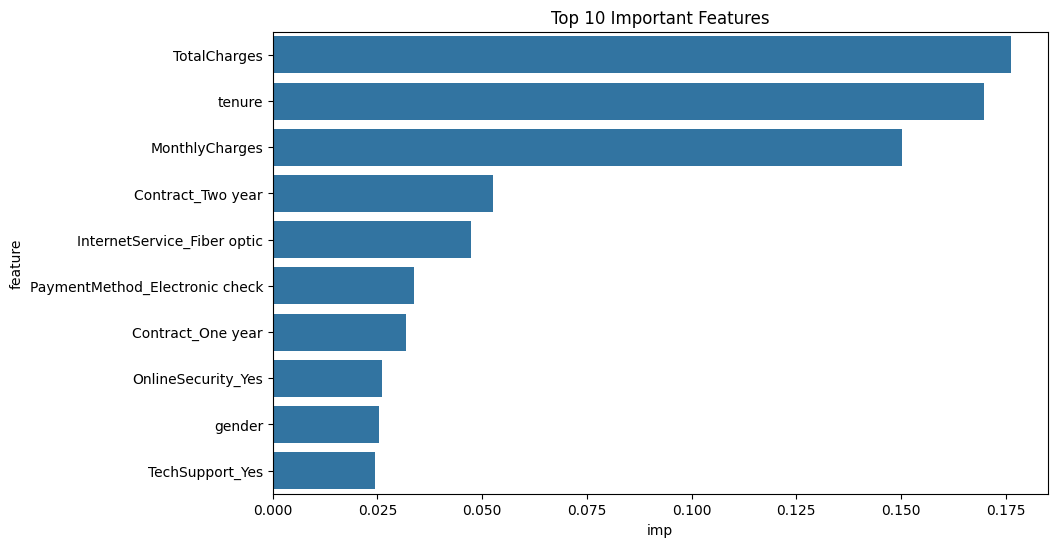

                           feature       imp
8                     TotalCharges  0.176213
4                           tenure  0.169829
7                   MonthlyCharges  0.150134
10               Contract_Two year  0.052547
14     InternetService_Fiber optic  0.047379
12  PaymentMethod_Electronic check  0.033789
9                Contract_One year  0.031826
19              OnlineSecurity_Yes  0.025993
0                           gender  0.025262
25                 TechSupport_Yes  0.024359


In [37]:
feature_imp=pd.DataFrame({'feature':X_train.columns,'imp':rf.feature_importances_})
feature_imp=feature_imp.sort_values('imp',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='imp',y='feature',data=feature_imp.head(10))
plt.title('Top 10 Important Features')
plt.show()
print(feature_imp.head(10))

In [ ]:
_imp